# First Jupyter Notebook
This notebook was created in your home directory.

In [5]:
print("Hello from your first notebook!")

Hello from your first notebook!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the data from file

In [7]:
df = pd.read_csv("train_data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Description: Utility functions for data cleaning

In [8]:
def drop_columns(df, columns):
    """
    Drop one or more columns from a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame from which columns will be removed.

    columns : str or list of str
        The column name or collection of column names to drop.
        Examples:
        - "PassengerId"
        - ["PassengerId", "Cabin", "Ticket"]

    Returns
    -------
    pandas.DataFrame
        A new DataFrame with the specified columns removed.

    Raises
    ------
    TypeError
        If `columns` is not a string, list, tuple, or set.
    KeyError
        If one or more specified columns do not exist in the DataFrame.

    Examples
    --------
    Drop a single column:
    >>> df = drop_columns(df, "PassengerId")

    Drop multiple columns:
    >>> df = drop_columns(df, ["PassengerId", "Cabin"])

    Notes
    -----
    This function does not modify the original DataFrame in place.
    It returns a new DataFrame.
    """
    if isinstance(columns, str):
        columns = [columns]
    elif not isinstance(columns, (list, tuple, set)):
        raise TypeError("`columns` must be a string, list, tuple, or set of column names.")

    missing_columns = [col for col in columns if col not in df.columns]
    if missing_columns:
        raise KeyError(f"The following columns do not exist in the DataFrame: {missing_columns}")

    return df.drop(columns=list(columns))

In [9]:
def convert_column_to_boolean(df, column_name, drop_original=True):
    """
    Convert a DataFrame column into a boolean indicator column.

    The new column is named "Has<ColumnName>" and contains:
    - 0 if the original value is NaN or an empty string
    - 1 for any other value

    If the original column contains string values, leading and trailing
    whitespace is removed before evaluating whether the value is empty.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    column_name : str
        The name of the column to convert.
    drop_original : bool, default=True
        If True, remove the original column after creating the boolean column.
        If False, keep the original column.

    Returns
    -------
    pandas.DataFrame
        A new DataFrame with a boolean indicator column named "Has<ColumnName>".

    Raises
    ------
    KeyError
        If `column_name` does not exist in the DataFrame.

    Examples
    --------
    >>> df = convert_column_to_boolean(df, "Cabin")
    >>> df[["HasCabin"]].head()

    >>> df = convert_column_to_boolean(df, "Age", drop_original=False)
    >>> df[["Age", "HasAge"]].head()
    """
    if column_name not in df.columns:
        raise KeyError(f"Column '{column_name}' does not exist in the DataFrame.")

    new_df = df.copy()

    def to_boolean_flag(value):
        if pd.isna(value):
            return 0
        if isinstance(value, str):
            value = value.strip()
            return 0 if value == "" else 1
        return 1

    new_column_name = f"Has{column_name}"
    new_df[new_column_name] = new_df[column_name].apply(to_boolean_flag)

    if drop_original:
        new_df = new_df.drop(columns=[column_name])

    return new_df

In [10]:
# Applying data cleaning

df = drop_columns(df, ["PassengerId", "Name"])
df = convert_column_to_boolean(df, "Cabin")
df = convert_column_to_boolean(df, "Age", drop_original=False)
df["Age"] = df["Age"].fillna(-1)

nan_rows = df[df.isna().any(axis=1)].index
df = df.drop(index=nan_rows)

print(f"Dropped {len(nan_rows)} rows with NaN values.")
df.head()

Dropped 2 rows with NaN values.


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,HasAge
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S,0,1
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,1,1
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1
3,1,1,female,35.0,1,0,113803,53.1000,S,1,1
4,0,3,male,35.0,0,0,373450,8.0500,S,0,1


EDA utility functions

In [11]:
import pandas as pd
import numpy as np


def summary_statistics(df, columns=None, include_categorical=True):
    """
    Generate summary statistics for a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame to analyze.
    columns : str or list of str, optional
        A column name or list of column names to include.
        If None, all columns are analyzed.
    include_categorical : bool, default=True
        If True, include summary statistics for categorical columns.
        If False, return only numeric summary statistics.

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing summary statistics.

    Raises
    ------
    TypeError
        If `columns` is not None, a string, or a list/tuple of strings.
    KeyError
        If any specified column does not exist in the DataFrame.

    Examples
    --------
    >>> summary_statistics(df)
    >>> summary_statistics(df, columns=["Age", "Fare"])
    >>> summary_statistics(df, include_categorical=False)
    """
    if columns is None:
        selected_df = df
    else:
        if isinstance(columns, str):
            columns = [columns]
        elif not isinstance(columns, (list, tuple)):
            raise TypeError("`columns` must be None, a string, or a list/tuple of strings.")

        missing_columns = [col for col in columns if col not in df.columns]
        if missing_columns:
            raise KeyError(f"These columns do not exist in the DataFrame: {missing_columns}")

        selected_df = df[columns]

    if include_categorical:
        return selected_df.describe(include="all").transpose()

    return selected_df.describe().transpose()


def grouped_or_filtered_view(
    df,
    group_by=None,
    metrics=None,
    filters=None,
    aggfunc="mean"
):
    """
    Create a grouped or filtered view of a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    group_by : str or list of str, optional
        Column name or list of column names to group by.
        If None, only filtering is applied and the filtered DataFrame is returned.
    metrics : str or list of str, optional
        Numeric column name or list of column names to aggregate.
        If None and group_by is provided, all numeric columns are used.
    filters : dict, optional
        Dictionary of filters to apply before grouping.
        Keys are column names and values are filter values.
        Examples:
        - {"Sex": "female"}
        - {"Pclass": 1, "Embarked": "S"}
        - {"Pclass": [1, 2]}  # keeps rows where Pclass is 1 or 2
    aggfunc : str or dict, default="mean"
        Aggregation function to apply when grouping.
        Examples: "mean", "sum", "median", "count"

    Returns
    -------
    pandas.DataFrame
        A filtered DataFrame if `group_by` is None, otherwise a grouped summary.

    Raises
    ------
    KeyError
        If any specified column does not exist in the DataFrame.

    Examples
    --------
    >>> grouped_or_filtered_view(df, filters={"Sex": "female"})
    >>> grouped_or_filtered_view(df, group_by="Pclass", metrics="Fare")
    >>> grouped_or_filtered_view(df, group_by=["Sex", "Pclass"], metrics=["Age", "Fare"])
    >>> grouped_or_filtered_view(df, filters={"Pclass": [1, 2]}, group_by="Sex", metrics="Fare", aggfunc="median")
    """
    result_df = df.copy()

    if filters is not None:
        missing_filter_cols = [col for col in filters if col not in result_df.columns]
        if missing_filter_cols:
            raise KeyError(f"These filter columns do not exist in the DataFrame: {missing_filter_cols}")

        for column, value in filters.items():
            if isinstance(value, (list, tuple, set)):
                result_df = result_df[result_df[column].isin(value)]
            else:
                result_df = result_df[result_df[column] == value]

    if group_by is None:
        return result_df

    if isinstance(group_by, str):
        group_by = [group_by]

    missing_group_cols = [col for col in group_by if col not in result_df.columns]
    if missing_group_cols:
        raise KeyError(f"These group-by columns do not exist in the DataFrame: {missing_group_cols}")

    if metrics is None:
        metrics = result_df.select_dtypes(include=np.number).columns.tolist()
        metrics = [col for col in metrics if col not in group_by]
    elif isinstance(metrics, str):
        metrics = [metrics]

    missing_metric_cols = [col for col in metrics if col not in result_df.columns]
    if missing_metric_cols:
        raise KeyError(f"These metric columns do not exist in the DataFrame: {missing_metric_cols}")

    grouped_df = result_df.groupby(group_by)[metrics].agg(aggfunc)
    return grouped_df.reset_index()


def correlation_checks(df, columns=None, method="pearson"):
    """
    Compute correlations between numeric columns in a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    columns : str or list of str, optional
        Numeric column name or list of numeric column names to include.
        If None, all numeric columns are used.
    method : str, default="pearson"
        Correlation method to use.
        Options include:
        - "pearson"
        - "spearman"
        - "kendall"

    Returns
    -------
    pandas.DataFrame
        A correlation matrix for the selected numeric columns.

    Raises
    ------
    TypeError
        If `columns` is not None, a string, or a list/tuple of strings.
    KeyError
        If any specified column does not exist in the DataFrame.
    ValueError
        If fewer than two numeric columns are available for correlation.

    Examples
    --------
    >>> correlation_checks(df)
    >>> correlation_checks(df, columns=["Age", "Fare", "Survived"])
    >>> correlation_checks(df, method="spearman")
    """
    if columns is None:
        selected_df = df.select_dtypes(include=np.number)
    else:
        if isinstance(columns, str):
            columns = [columns]
        elif not isinstance(columns, (list, tuple)):
            raise TypeError("`columns` must be None, a string, or a list/tuple of strings.")

        missing_columns = [col for col in columns if col not in df.columns]
        if missing_columns:
            raise KeyError(f"These columns do not exist in the DataFrame: {missing_columns}")

        selected_df = df[columns].select_dtypes(include=np.number)

    if selected_df.shape[1] < 2:
        raise ValueError("At least two numeric columns are required to compute correlation.")

    return selected_df.corr(method=method)

In [12]:
# 1. Summary statistics
summary_all = summary_statistics(df)
summary_all

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,889.0,NaN,NaN,NaN,0.382452,0.48626,0.0,0.0,0.0,1.0,1.0
Pclass,889.0,NaN,NaN,NaN,2.311586,0.8347,1.0,2.0,3.0,3.0,3.0
Sex,889,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,889.0,NaN,NaN,NaN,23.541249,17.834487,-1.0,6.0,24.0,35.0,80.0
SibSp,889.0,NaN,NaN,NaN,0.524184,1.103705,0.0,0.0,0.0,1.0,8.0
Parch,889.0,NaN,NaN,NaN,0.382452,0.806761,0.0,0.0,0.0,0.0,6.0
Ticket,889,680,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,889.0,NaN,NaN,NaN,32.096681,49.697504,0.0,7.8958,14.4542,31.0,512.3292
Embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasCabin,889.0,NaN,NaN,NaN,0.227222,0.419273,0.0,0.0,0.0,0.0,1.0


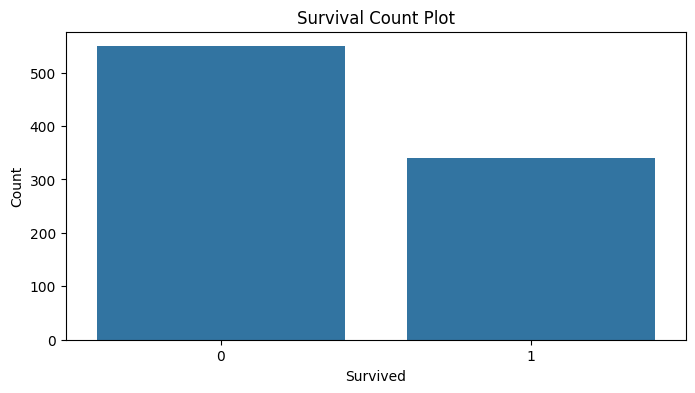

In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count Plot")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [14]:
# Numeric only
summary_numeric = summary_statistics(df, include_categorical=False)
summary_numeric

,count,mean,std,min,25%,50%,75%,max
Survived,889.0,0.382452,0.486260,0.0,0.0000,0.0000,1.0,1.0000
Pclass,889.0,2.311586,0.834700,1.0,2.0000,3.0000,3.0,3.0000
Age,889.0,23.541249,17.834487,-1.0,6.0000,24.0000,35.0,80.0000
SibSp,889.0,0.524184,1.103705,0.0,0.0000,0.0000,1.0,8.0000
Parch,889.0,0.382452,0.806761,0.0,0.0000,0.0000,0.0,6.0000
Fare,889.0,32.096681,49.697504,0.0,7.8958,14.4542,31.0,512.3292
HasCabin,889.0,0.227222,0.419273,0.0,0.0000,0.0000,0.0,1.0000
HasAge,889.0,0.800900,0.399548,0.0,1.0000,1.0000,1.0,1.0000


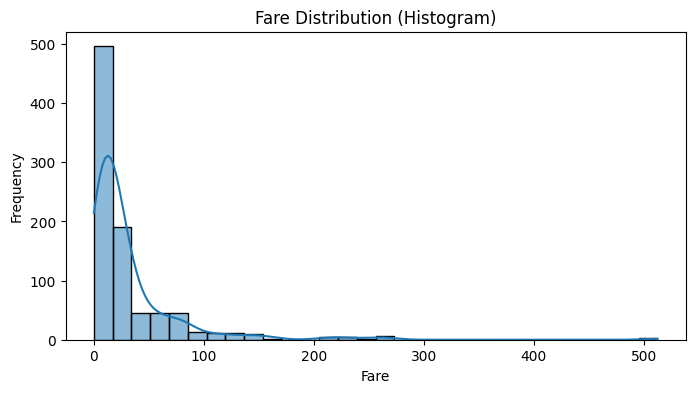

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution (Histogram)")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [16]:
# 2. Grouped or filtered views
female_view = grouped_or_filtered_view(df, filters={"Sex": "female"})
female_view.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,HasAge
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,1,1
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1
3,1,1,female,35.0,1,0,113803,53.1000,S,1,1
8,1,3,female,27.0,0,2,347742,11.1333,S,0,1
9,1,2,female,14.0,1,0,237736,30.0708,C,0,1


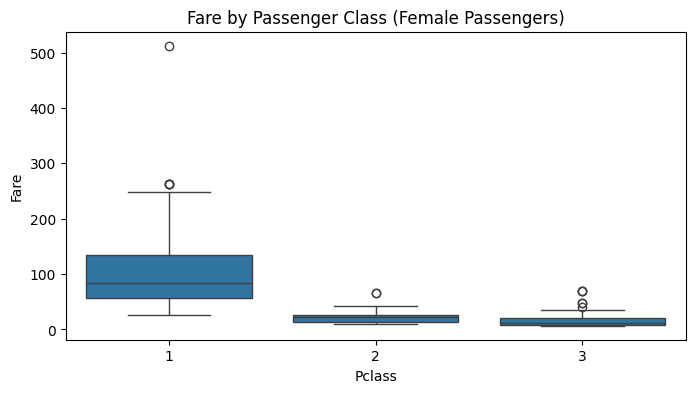

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=female_view, x="Pclass", y="Fare")
plt.title("Fare by Passenger Class (Female Passengers)")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

In [18]:
pclass_grouped = grouped_or_filtered_view(
    df,
    group_by="Pclass",
    metrics=["Age", "Fare", "Survived"],
    aggfunc="mean"
)
pclass_grouped

,Pclass,Age,Fare,Survived
0,1,32.623458,84.193516,0.626168
1,2,28.031685,20.662183,0.472826
2,3,17.900041,13.675550,0.242363


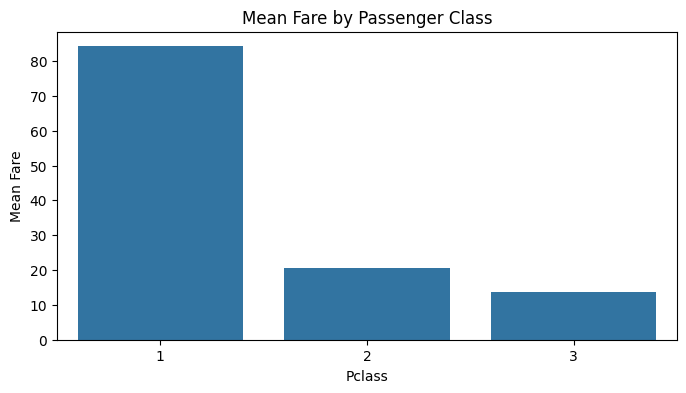

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(data=pclass_grouped, x="Pclass", y="Fare")
plt.title("Mean Fare by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Mean Fare")
plt.show()

In [20]:
sex_pclass_embarked_grouped = grouped_or_filtered_view(
    df,
    filters={"Embarked": "S"},
    group_by=["Sex", "Pclass"],
    metrics="Survived",
    aggfunc="mean"
)
sex_pclass_embarked_grouped

,Sex,Pclass,Survived
0,female,1,0.958333
1,female,2,0.910448
2,female,3,0.375000
3,male,1,0.354430
4,male,2,0.154639
5,male,3,0.128302


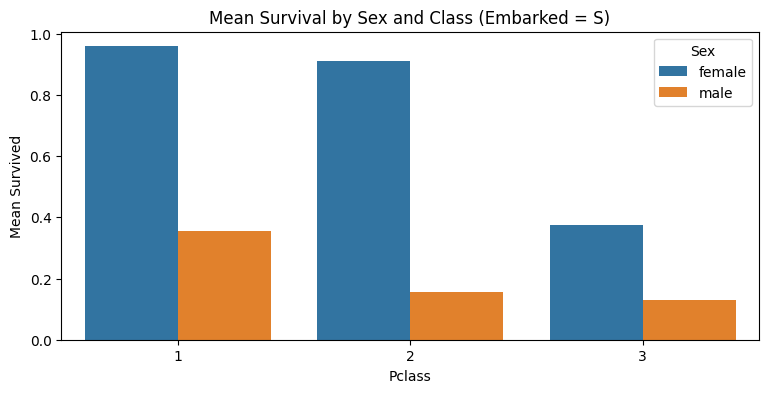

In [21]:
plt.figure(figsize=(9, 4))
sns.barplot(data=sex_pclass_embarked_grouped, x="Pclass", y="Survived", hue="Sex")
plt.title("Mean Survival by Sex and Class (Embarked = S)")
plt.xlabel("Pclass")
plt.ylabel("Mean Survived")
plt.show()

In [22]:
# 3. Correlation checks
corr_all = correlation_checks(df)
corr_all

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,HasAge
Survived,1.000000,-0.335549,0.008265,-0.034040,0.083151,0.255290,0.313435,0.090967
Pclass,-0.335549,1.000000,-0.356560,0.081656,0.016824,-0.548193,-0.723815,-0.171701
Age,0.008265,-0.356560,1.000000,-0.181288,-0.043838,0.133040,0.264169,0.686479
SibSp,-0.034040,0.081656,-0.181288,1.000000,0.414542,0.160887,-0.038657,-0.018436
Parch,0.083151,0.016824,-0.043838,0.414542,1.000000,0.217532,0.039101,0.124701
Fare,0.255290,-0.548193,0.133040,0.160887,0.217532,1.000000,0.480425,0.099761
HasCabin,0.313435,-0.723815,0.264169,-0.038657,0.039101,0.480425,1.000000,0.142636
HasAge,0.090967,-0.171701,0.686479,-0.018436,0.124701,0.099761,0.142636,1.000000


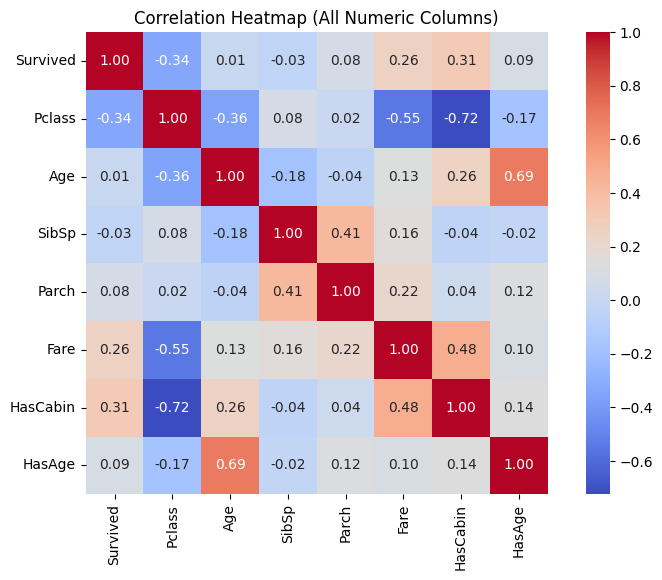

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_all, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (All Numeric Columns)")
plt.show()

In [24]:
corr_selected = correlation_checks(df, columns=["Survived", "Age", "Fare", "SibSp", "Parch"])
corr_selected

,Survived,Age,Fare,SibSp,Parch
Survived,1.000000,0.008265,0.255290,-0.034040,0.083151
Age,0.008265,1.000000,0.133040,-0.181288,-0.043838
Fare,0.255290,0.133040,1.000000,0.160887,0.217532
SibSp,-0.034040,-0.181288,0.160887,1.000000,0.414542
Parch,0.083151,-0.043838,0.217532,0.414542,1.000000


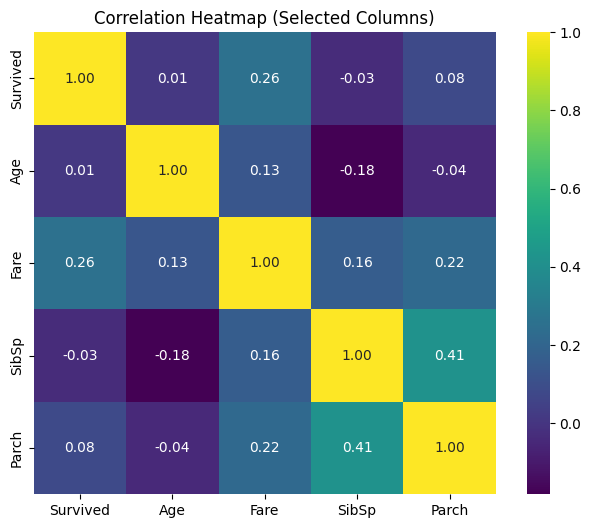

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_selected, annot=True, cmap="viridis", fmt=".2f", square=True)
plt.title("Correlation Heatmap (Selected Columns)")
plt.show()

## Summary and interpretation

The analysis showed that survival on the Titanic was strongly associated with passenger class, fare, sex, and whether cabin information was recorded. First-class passengers had much higher survival rates than third-class passengers, and women survived at much higher rates than men across all classes. Fare and survival were positively related, while passenger class showed a clear negative relationship with survival because lower-class passengers were less likely to survive. One limitation of the data is that missing age values were too many, about 20%, which may distort age-based statistics and correlations. Overall, the dataset reveals clear social and demographic patterns, but some variables would benefit from more careful treatment of missing data.

The fact that gender came out as factor in survival rate is shocking.